# LUCC Discrete (CLUE-S) — a synthetic example

This notebook builds and runs a small, fully synthetic land-use-change
scenario with `disslucc`'s discrete (CLUE-S-like) allocation -- no
shapefiles, no real data, just a deterministic `np.random` landscape,
small enough to read and run cell by cell.

For the real validated scenario (Lab15, at exact cell-by-cell agreement
against the original TerraME reference), see
[`examples/run_lab15_via_executor.py`](https://github.com/DisSModel/disslucc/blob/main/examples/run_lab15_via_executor.py) and
[Validation](../../validation.md) instead -- this notebook is for
understanding the mechanics, not for validation.

## Continuous vs discrete, in one line

Continuous CLUE allocates a *fraction* of each cell to each class
(soft competition). Discrete CLUE-S gives each cell to exactly **one**
class (hard competition, binary 0/1 arrays) and adds a
`transition_matrix`: which class-to-class changes are even allowed.
That's the mechanism behind irreversible change -- e.g. "forest can
become agriculture, agriculture can become urban, but urban never
reverts to forest".

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dissmodel.core import Environment
from dissmodel.geo import RasterBackend

from disslucc import AllocationDClueSLike, DemandInline, PotentialDLogisticRegression
from disslucc.schemas import LogisticRegressionSpec

## Building a synthetic landscape

Same idea as the continuous notebook -- `dist_road` and `slope` as
synthetic drivers -- but a smaller 20×20 grid (discrete allocation is
the same iterative competition, cell by cell, so a smaller grid keeps
this fast) and land use starts strictly binary: every cell is exactly
one class.

In [2]:
HEIGHT = WIDTH = 20
LAND_USE_TYPES = ["forest", "agriculture", "urban"]

rng = np.random.default_rng(7)

road_row = HEIGHT // 2
rows = np.arange(HEIGHT, dtype=np.float32)[:, None]
dist_road = np.repeat(np.abs(rows - road_row), WIDTH, axis=1)
dist_road = dist_road / dist_road.max()

yy, xx = np.mgrid[0:HEIGHT, 0:WIDTH]
slope = (
    np.sin(xx / 4.0) * 0.5 + np.cos(yy / 5.0) * 0.5
    + rng.normal(0, 0.05, size=(HEIGHT, WIDTH))
).astype(np.float32)
slope = (slope - slope.min()) / (slope.max() - slope.min())

backend = RasterBackend(shape=(HEIGHT, WIDTH))
backend.set("dist_road", dist_road.astype(np.float32))
backend.set("slope", slope)

urban = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
urban[road_row, WIDTH // 2] = 1.0  # a single seed cell
agriculture = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
forest = 1.0 - urban - agriculture  # everything else starts as forest
backend.set("urban", urban)
backend.set("agriculture", agriculture)
backend.set("forest", forest)

## Demand

Same idea as the continuous notebook: target cell *counts* (not
fractions) per class, per step.

In [3]:
N_STEPS = 8
total = HEIGHT * WIDTH

demand_matrix = []
for step in range(N_STEPS):
    urban_target = 1 + 2 * step
    agri_target = 1 * step
    forest_target = total - urban_target - agri_target
    demand_matrix.append([float(forest_target), float(agri_target), float(urban_target)])

demand_matrix[:3]  # first 3 steps, [forest, agriculture, urban]

[[399.0, 0.0, 1.0], [396.0, 1.0, 3.0], [393.0, 2.0, 5.0]]

## Potential: logistic, not linear

Discrete CLUE-S scores suitability with a logistic regression
(`prob = sigmoid(const + sum(beta * driver))`), plus an optional
`elasticity` term that reinforces a cell's *current* class -- the
higher it is, the more "locked in" a pixel stays once it changes
(spatial lock-in, e.g. urban rarely reverts once built).

```python
potential = PotentialDLogisticRegression(
    backend=backend,
    land_use_types=LAND_USE_TYPES,
    potential_data=[[
        LogisticRegressionSpec(const=0.5, betas={"slope": 0.3}),                                    # forest
        LogisticRegressionSpec(const=-0.5, elasticity=0.3, betas={"dist_road": -0.3, "slope": -0.2}), # agriculture
        LogisticRegressionSpec(const=-1.0, elasticity=0.6, betas={"dist_road": -0.8}),                # urban
    ]],
)
```

(This constructs the model, but note it needs an active `Environment` — see below where it's built for real.)


## Allocation: the transition matrix

`transition_matrix[region][from][to]` -- `1` if that class-to-class
change is allowed, `0` if not. One region here, so a single 3×3
matrix. This one enforces a one-way deforestation frontier: forest can
only turn into forest or agriculture; agriculture into agriculture or
urban; urban never reverts.

Note `AllocationDClueSLike` doesn't take `potential=` directly (unlike
the continuous `AllocationClueLike`) -- it reads the `<land_use>_pot`
bands that `PotentialDLogisticRegression` writes to the shared
`backend` instead.

In [4]:
transition_matrix = [[
    [1, 1, 0],   # forest    -> forest, agriculture
    [0, 1, 1],   # agriculture -> agriculture, urban
    [0, 0, 1],   # urban     -> urban only
]]

env = Environment(end_time=N_STEPS - 1)

demand = DemandInline(values=demand_matrix, land_use_types=LAND_USE_TYPES)

# re-declared after Environment so Demand/Potential/Allocation connect
# to *this* environment, in order
potential = PotentialDLogisticRegression(
    backend=backend,
    land_use_types=LAND_USE_TYPES,
    potential_data=[[
        LogisticRegressionSpec(const=0.5, betas={"slope": 0.3}),
        LogisticRegressionSpec(const=-0.5, elasticity=0.3, betas={"dist_road": -0.3, "slope": -0.2}),
        LogisticRegressionSpec(const=-1.0, elasticity=0.6, betas={"dist_road": -0.8}),
    ]],
)

allocation = AllocationDClueSLike(
    backend=backend,
    demand=demand,
    land_use_types=LAND_USE_TYPES,
    transition_matrix=transition_matrix,
    cell_area=1.0,
    max_difference=5.0,
    factor_iteration=0.0001,
)

## Running the simulation

In [5]:
env.run()

Running from 0 to 7 (duration: 7)


## Result

Each class is strictly binary now -- every cell belongs to exactly one
class -- so the counts below are cell counts, not fractions.

In [6]:
print("Cell count per class after", N_STEPS - 1, "steps:")
for lu in LAND_USE_TYPES:
    print(f"  {lu:>12}: {float(backend.get(lu).sum()):8.1f}")

print("\nLast-step demand target vs allocated:")
for i, lu in enumerate(LAND_USE_TYPES):
    target = demand_matrix[-1][i]
    actual = float(backend.get(lu).sum())
    print(f"  {lu:>12}: target={target:8.1f}  allocated={actual:8.1f}  diff={abs(target - actual):6.2f}")

Cell count per class after 7 steps:
        forest:    381.0
   agriculture:      9.0
         urban:     10.0

Last-step demand target vs allocated:
        forest: target=   378.0  allocated=   381.0  diff=  3.00
   agriculture: target=     7.0  allocated=     9.0  diff=  2.00
         urban: target=    15.0  allocated=    10.0  diff=  5.00


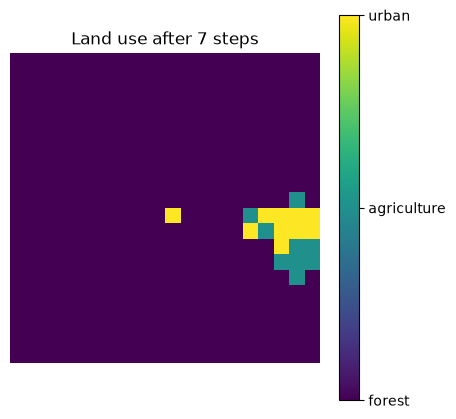

In [7]:
# one categorical band: the class index (0/1/2) each cell belongs to
class_code = np.zeros((HEIGHT, WIDTH), dtype=np.int8)
for i, lu in enumerate(LAND_USE_TYPES):
    class_code[backend.get(lu) == 1] = i

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(class_code, cmap="viridis", vmin=0, vmax=len(LAND_USE_TYPES) - 1)
cbar = fig.colorbar(im, ticks=range(len(LAND_USE_TYPES)))
cbar.ax.set_yticklabels(LAND_USE_TYPES)
ax.set_title(f"Land use after {N_STEPS - 1} steps")
ax.axis("off")
plt.show()

## Try it yourself

Go back and experiment:

- Remove an allowed transition in `transition_matrix` (e.g. forbid
  `agriculture -> urban`) and see how the allocation adapts
- Raise `elasticity` on `urban` further and see the class "stick"
  harder around its seed
- Add a second region (`region` band on the backend, an extra row in
  `potential_data`/`transition_matrix`) with different coefficients

For the same model driven by real data and validated against TerraME
at exact cell-by-cell agreement, see
[`examples/run_lab15_via_executor.py`](https://github.com/DisSModel/disslucc/blob/main/examples/run_lab15_via_executor.py) and
[Validation](../../validation.md). For automatic provenance
(`ModelExecutor`/`ExperimentRecord`, a CLI), see
[API Reference](../../api.md#executors-dissluccexecutors).